<a href="https://colab.research.google.com/github/cgm2179/Algoverse-Research-phases/blob/main/Tier2_estimation_cost_vs_rank.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tier 2 — Estimation Cost vs Rank: does $M^\ast(r)$ grow with the predicted slopes?

Tier 1 showed the alignment laws hold and that the rank sweep has an Eckart–Young knee. Tier 2 tests the **estimation side** of the folded rank-sweep prediction: how the number of probes needed to reach a target alignment, $M^\ast(r)=\tfrac{a}{1-a}\,(D_\text{eff}(r)+1)$, grows with LoRA rank $r$ for each estimator.

$$\textbf{weight: } D_\text{eff}=P=r(m+n)\quad(\text{slope } m+n)\qquad\qquad \textbf{node: } D_\text{eff}=\bar d=(1-\beta)r+\beta m\quad(\text{slope}\approx 1-\beta)$$

The claim: **node estimation cost grows $\sim(m+n)$ times more slowly per rank than weight.** GPU-ready; also runs on CPU.

> Uses the corrected Tier-1 recipe (per-element loss, converged base). Verified end-to-end offline before shipping.


## Setup, data, model — same corrected recipe as Tier 1

In [1]:
import torch, numpy as np, matplotlib.pyplot as plt
torch.set_default_dtype(torch.float64)
dev = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(0); np.random.seed(0)
print("device:", dev)

device: cuda


In [2]:
try:
    import torchvision
    ds = torchvision.datasets.MNIST(root="./data", train=True, download=True)
    imgs = ds.data[:2000].to(dev).double().view(-1, 784) / 255.0
    X0 = imgs*2-1; X0 = X0 - X0.mean(0); X0 = X0/X0.std()
    d, H, DATA = 784, 256, "MNIST(2000)"
except Exception as e:
    print("torchvision/MNIST unavailable -> synthetic:", type(e).__name__)
    klat=20; Db=torch.randn(64,klat,device=dev)/klat**0.5
    X0=(torch.randn(1024,klat,device=dev)@Db.t()); X0=X0/X0.std(); d,H,DATA=64,128,"synthetic"
print(f"data: {DATA} | d={d} H={H} N={len(X0)}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 14.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 337kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.18MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.0MB/s]


data: MNIST(2000) | d=784 H=256 N=2000


In [3]:
T=50; betas=torch.linspace(1e-4,0.02,T,device=dev); abar=torch.cumprod(1-betas,0)
# config
ranks   = [2,4,8,16,32]
Ms      = [8,32,128]     # probe budgets used to fit D_eff
reps    = 400            # <- slow cell; raise on GPU for cleaner fits
mu      = 1e-4
target_a= 0.9            # target alignment for M*(r)
pre_steps, pre_lr = 3000, 1e-3

def rp(*s): return torch.randn(*s,device=dev)/s[-1]**0.5
W1=rp(H,d+1).requires_grad_(); b1=torch.zeros(H,device=dev,requires_grad=True)
W2=rp(H,H).requires_grad_(); W3=rp(d,H).requires_grad_()
def make_batch(data,bs):
    i=torch.randint(0,len(data),(bs,),device=dev); t=torch.randint(0,T,(bs,),device=dev); e=torch.randn(bs,d,device=dev)
    return abar[t].sqrt()[:,None]*data[i]+(1-abar[t]).sqrt()[:,None]*e, t.double()/T, e
def h1_of(xt,tn): return torch.tanh(torch.cat([xt,tn[:,None]],1)@W1.t()+b1)
def forward(xt,tn,A,B): h=h1_of(xt,tn); return torch.tanh(h@W2.t()+(h@A.t())@B.t())@W3.t()
def dloss(xt,tn,e,A,B): return 0.5*((forward(xt,tn,A,B)-e)**2).mean()
print("model ready")

model ready


In [4]:
A0=torch.zeros(1,H,device=dev); B0=torch.zeros(H,1,device=dev)
opt=torch.optim.Adam([W1,b1,W2,W3],lr=pre_lr)
for s in range(pre_steps):
    xt,tn,e=make_batch(X0,128); opt.zero_grad(); L=dloss(xt,tn,e,A0,B0); L.backward(); opt.step()
for p in (W1,b1,W2,W3): p.requires_grad_(False)
Lp=L.item(); print(f"base pretrained; loss={Lp:.4f} (predict-zero=0.5)")
if Lp>0.48: print("  WARNING: base did not converge; lower pre_lr or raise pre_steps.")

base pretrained; loss=0.3676 (predict-zero=0.5)


## Measuring the effective dimension

Both alignment laws have the form $\cos^2\theta=\dfrac{M}{M+D+1}$, so

$$\frac{1}{\cos^2\theta}=1+\frac{D+1}{M}$$

is **linear in $1/M$ with slope $D+1$**. So we measure $\cos^2\theta$ at a few probe budgets $M$, fit a line to $1/\cos^2\theta$ vs $1/M$, and read off $D_\text{eff}=\text{slope}-1$ — separately for weight and node perturbation, at each rank. Then $M^\ast(r)=\tfrac{a}{1-a}(D_\text{eff}+1)$.

In [5]:
def measure_Deff(r):
    A=rp(r,H).requires_grad_(); B=rp(H,r).requires_grad_()
    xt,tn,e=make_batch(X0,1); L=dloss(xt,tn,e,A,B); L.backward()
    gA,gB=A.grad.clone(),B.grad.clone(); g=torch.cat([gA.flatten(),gB.flatten()]); gn2=(g@g).item()
    beta=(gB**2).sum().item()/((gA**2).sum().item()+(gB**2).sum().item())
    dbar=(1-beta)*r+beta*H; P=r*(H+H)
    with torch.no_grad():
        h1=h1_of(xt,tn); z0=h1@A.t(); u0=z0@B.t()
        def Lf(A_=A,B_=B,z=None,u=None):
            zz=h1@A_.t() if z is None else z; uu=zz@B_.t() if u is None else u
            return 0.5*(((torch.tanh(h1@W2.t()+uu)@W3.t())-e)**2).mean()
        def zw():
            xa=torch.randn(r,H,device=dev); xb=torch.randn(H,r,device=dev)
            dd=(Lf(A+mu*xa,B+mu*xb)-Lf(A-mu*xa,B-mu*xb))/(2*mu)
            return torch.cat([(dd*xa).flatten(),(dd*xb).flatten()])
        def zn():
            xz=torch.randn(1,r,device=dev); gz=((Lf(z=z0+mu*xz)-Lf(z=z0-mu*xz))/(2*mu))*xz
            xu=torch.randn(1,H,device=dev); gu=((Lf(u=u0+mu*xu)-Lf(u=u0-mu*xu))/(2*mu))*xu
            return torch.cat([torch.outer(gz.flatten(),h1.flatten()).flatten(),
                              torch.outer(gu.flatten(),z0.flatten()).flatten()])
        def Deff(fn):
            inv=[]
            for M in Ms:
                num=den=0.0
                for _ in range(reps):
                    acc=torch.zeros_like(g)
                    for _ in range(M): acc=acc+fn()
                    acc/=M; num+=(acc@g).item(); den+=(acc@acc).item()
                inv.append(gn2*den/reps/(num/reps)**2)   # 1/cos^2
            slope=np.polyfit([1.0/M for M in Ms], inv, 1)[0]
            return slope-1.0
        return dict(beta=beta,dbar=dbar,P=P,Dw=Deff(zw),Dn=Deff(zn))

R={}
print(f"{'r':>3} {'P':>7} {'Dw meas':>8} | {'dbar':>7} {'Dn meas':>8} {'beta':>6}")
for r in ranks:
    R[r]=measure_Deff(r)
    print(f"{r:>3} {R[r]['P']:>7} {R[r]['Dw']:>8.0f} | {R[r]['dbar']:>7.2f} {R[r]['Dn']:>8.2f} {R[r]['beta']:>6.3f}")

  r       P  Dw meas |    dbar  Dn meas   beta
  2    1024     1068 |    2.00     1.86  0.000
  4    2048     2129 |    4.13     3.69  0.001
  8    4096     4000 |    8.14     8.07  0.001
 16    8192     8018 |   16.74    16.77  0.003
 32   16384    15560 |   38.82    40.91  0.030


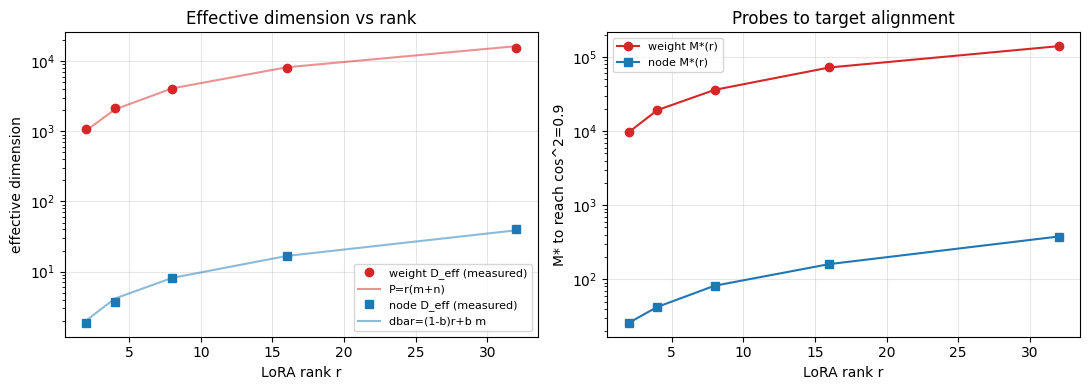

node slope   dD/dr = 1.30  (predicted ~1-beta)
weight slope dD/dr = 482.6  (predicted m+n = 512)


In [6]:
rs=np.array(ranks)
Dn=np.array([R[r]['Dn'] for r in ranks]); Dw=np.array([R[r]['Dw'] for r in ranks])
dbar=np.array([R[r]['dbar'] for r in ranks]); P=np.array([R[r]['P'] for r in ranks])
c=target_a/(1-target_a)
fig,ax=plt.subplots(1,2,figsize=(11,4))
ax[0].plot(rs,Dw,"o",color="C3",label="weight D_eff (measured)"); ax[0].plot(rs,P,"-",color="C3",alpha=.5,label="P=r(m+n)")
ax[0].plot(rs,Dn,"s",color="C0",label="node D_eff (measured)");   ax[0].plot(rs,dbar,"-",color="C0",alpha=.5,label="dbar=(1-b)r+b m")
ax[0].set_yscale("log"); ax[0].set_xlabel("LoRA rank r"); ax[0].set_ylabel("effective dimension"); ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)
ax[0].set_title("Effective dimension vs rank")
ax[1].plot(rs,c*(Dw+1),"o-",color="C3",label="weight M*(r)"); ax[1].plot(rs,c*(Dn+1),"s-",color="C0",label="node M*(r)")
ax[1].set_yscale("log"); ax[1].set_xlabel("LoRA rank r"); ax[1].set_ylabel(f"M* to reach cos^2={target_a}"); ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)
ax[1].set_title("Probes to target alignment")
plt.tight_layout(); plt.show()
print(f"node slope   dD/dr = {np.polyfit(rs,Dn,1)[0]:.2f}  (predicted ~1-beta)")
print(f"weight slope dD/dr = {np.polyfit(rs,Dw,1)[0]:.1f}  (predicted m+n = {2*H})")

**How to read it.**

- **Weight** $D_\text{eff}$ lands on $P=r(m+n)$ (slope $m+n$); **node** $D_\text{eff}$ lands on $\bar d=(1-\beta)r+\beta m$ (slope $\approx 1$, curving up slightly as $\beta$ grows with $r$).
- The right panel is the payoff: to reach the same alignment, node perturbation needs $\sim(m+n)$-fold fewer probes per unit rank. At $H=256$ that is a two-order-of-magnitude gap in $M^\ast$.

**Falsification.**
- If measured $D_\text{eff}$ does not track its prediction, suspect finite-$\mu$ bias (shrink `mu`) or too few `reps` (the $1/\cos^2$ fit is noisy for weight at small $M$).
- The two slopes must differ by $\sim(m+n)$; if they don't, the node estimator is not exploiting the bottleneck.

**Caveat.** This is the *estimation* cost only. The *approximation* floor (Eckart–Young knee, Tier 1) still caps what any rank can achieve; the efficient operating point is the min of estimation cost subject to clearing that floor.

## What Tier 2 establishes — and Tier 3

**Established:** the estimation cost $M^\ast(r)$ is linear in rank with the predicted slopes, and node perturbation's slope is smaller by $\sim(m+n)$ — the quantitative payoff of perturbing the bottleneck instead of the weights, now measured, not just derived.

**Tier 3 (TPU v5e/v6e):** move to the open-weight diffusion backbone; identify which layer carries a local residual channel (convolutional/U-Net-style vs attention), and post-train that segment with node perturbation, using the measured $\bar d$ to budget probes.